# ResNet-50 + Fourier — teljes teszthalmaz kiértékelő notebook

Ez a notebook **nem tanít újra modellt**.  
A célja:

- betölti a mentett `best_resnet50_fourier.pth` modellt,
- beolvassa a BRISC test mappát,
- automatikusan felismeri az osztálymappákat,
- kiértékeli a modellt a testhalmazon,
- elkészíti:
  - accuracy / precision / recall / F1 táblázatot,
  - classification reportot,
  - confusion matrixot,
  - normalizált confusion matrixot,
  - képenkénti predikciós CSV-t,
  - hibásan klasszifikált képek CSV-jét.

**Fontos:** a checkpoint a tanítási osztálysorrend szerint ad kimenetet.  
Ezért a notebook a BRISC osztályneveket automatikusan normalizálja.

In [1]:
# Ha Colabban futtatod, ezt használd:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("Torch:", torch.__version__)
print("CUDA elérhető:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA elérhető: True


In [3]:
# =========================
# BEÁLLÍTÁSOK
# =========================

RESNET_CKPT = "/content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/checkpoints/best_resnet50_fourier.pth"

TEST_DIR = "/content/drive/MyDrive/Brain MRI/brisc2025/classification_task/test"

OUT_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

SEED = 42

# A modell tanításánál használt kanonikus osztálysorrend.
# Ezt NEM rendezzük abc szerint, mert a checkpoint kimenete ehhez az indexeléshez tartozik.
CANONICAL_CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Checkpoint:", RESNET_CKPT)
print("Test folder:", TEST_DIR)
print("Output folder:", OUT_DIR)

Device: cuda
Checkpoint: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/checkpoints/best_resnet50_fourier.pth
Test folder: /content/drive/MyDrive/Brain MRI/brisc2025/classification_task/test
Output folder: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL


In [4]:
# =========================
# ÚTVONALAK ELLENŐRZÉSE
# =========================

if not os.path.exists(RESNET_CKPT):
    raise FileNotFoundError(f"Checkpoint nem található: {RESNET_CKPT}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test mappa nem található: {TEST_DIR}")

print("Checkpoint létezik:", os.path.exists(RESNET_CKPT))
print("Test mappa létezik:", os.path.exists(TEST_DIR))

print("\nTest mappa tartalma:")
for item in sorted(os.listdir(TEST_DIR)):
    p = os.path.join(TEST_DIR, item)
    if os.path.isdir(p):
        n = len([f for f in os.listdir(p) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tif', '.tiff'))])
        print(f"  {item:25s} -> {n} kép")

Checkpoint létezik: True
Test mappa létezik: True

Test mappa tartalma:
  glioma                    -> 254 kép
  meningioma                -> 306 kép
  no_tumor                  -> 140 kép
  pituitary                 -> 300 kép


In [5]:
# =========================
# OSZTÁLYNÉV NORMALIZÁLÁS
# =========================
# A test mappák nevei lehetnek pl.:
# glioma, glioma_tumor, meningioma, meningioma_tumor, no_tumor, notumor, pituitary, pituitary_tumor stb.
# A modell viszont a tanítás szerint ezt várja:
# 0 = glioma, 1 = meningioma, 2 = no_tumor, 3 = pituitary

def normalize_folder_name(name: str) -> str:
    s = name.lower().strip()
    s = s.replace("-", "_").replace(" ", "_")

    if "glioma" in s:
        return "glioma"
    if "meningioma" in s:
        return "meningioma"
    if "pituitary" in s:
        return "pituitary"
    if s in ["no_tumor", "notumor", "no_tumour", "notumour", "normal", "healthy"]:
        return "no_tumor"
    if "no" in s and ("tumor" in s or "tumour" in s):
        return "no_tumor"

    return s

folder_rows = []
for folder_name in sorted(os.listdir(TEST_DIR)):
    folder_path = os.path.join(TEST_DIR, folder_name)
    if os.path.isdir(folder_path):
        canonical = normalize_folder_name(folder_name)
        folder_rows.append({
            "folder_name": folder_name,
            "canonical_label": canonical,
            "folder_path": folder_path
        })

folder_df = pd.DataFrame(folder_rows)
display(folder_df)

detected_labels = sorted(folder_df["canonical_label"].unique().tolist())
print("Detected canonical labels:", detected_labels)

missing = [c for c in CANONICAL_CLASS_NAMES if c not in detected_labels]
extra = [c for c in detected_labels if c not in CANONICAL_CLASS_NAMES]

if missing:
    print("FIGYELEM: ezek a kanonikus osztályok hiányoznak a test mappából:", missing)

if extra:
    print("FIGYELEM: ismeretlen plusz osztálymappák:", extra)

# A tényleges kiértékelésnél csak azokat vesszük figyelembe, amelyek a tanított osztályokhoz tartoznak.
CLASS_NAMES = CANONICAL_CLASS_NAMES
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
label_map_inv = {idx: name for name, idx in label_map.items()}

print("Használt modell-osztálysorrend:", CLASS_NAMES)
print("Label map:", label_map)

,folder_name,canonical_label,folder_path
0,glioma,glioma,/content/drive/MyDrive/Brain MRI/brisc2025/cla...
1,meningioma,meningioma,/content/drive/MyDrive/Brain MRI/brisc2025/cla...
2,no_tumor,no_tumor,/content/drive/MyDrive/Brain MRI/brisc2025/cla...
3,pituitary,pituitary,/content/drive/MyDrive/Brain MRI/brisc2025/cla...


Detected canonical labels: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Használt modell-osztálysorrend: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Label map: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [6]:
# =========================
# TEST DATAFRAME ÉPÍTÉSE
# =========================

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

rows = []

for _, r in folder_df.iterrows():
    folder_name = r["folder_name"]
    canonical_label = r["canonical_label"]
    folder_path = r["folder_path"]

    if canonical_label not in label_map:
        print(f"Kihagyva, mert nem ismert osztály: {folder_name} -> {canonical_label}")
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(valid_exts):
            rows.append({
                "image_path": os.path.join(folder_path, fname),
                "folder_label": folder_name,
                "label": canonical_label,
                "label_idx": label_map[canonical_label]
            })

df_test = pd.DataFrame(rows)

if len(df_test) == 0:
    raise RuntimeError("Nem találtam képeket a test mappában. Ellenőrizd a TEST_DIR útvonalat és az almappákat.")

print("Összes test kép:", len(df_test))
print("\nOsztályeloszlás:")
display(df_test["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame("count"))

csv_path = os.path.join(OUT_DIR, "test_file_list.csv")
df_test.to_csv(csv_path, index=False)
print("Test fájllista mentve:", csv_path)

display(df_test.head())

Összes test kép: 1000

Osztályeloszlás:


,count
label,
glioma,254
meningioma,306
no_tumor,140
pituitary,300


Test fájllista mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_file_list.csv


,image_path,folder_label,label,label_idx
0,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
1,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
2,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
3,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
4,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0


In [7]:
# =========================
# TRANSFORM ÉS DATASET
# =========================
# Testhalmazon nincs augmentáció, csak resize + normalize.

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BrainTumorTestDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row["image_path"]
        label_idx = int(row["label_idx"])

        img = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label_idx, image_path

test_dataset = BrainTumorTestDataset(df_test, transform=eval_transforms)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Test dataset méret:", len(test_dataset))
print("Batch-ek száma:", len(test_loader))

Test dataset méret: 1000
Batch-ek száma: 63


In [8]:
# =========================
# MODELL ARCHITEKTÚRA
# A tanítási notebookból átvett ResNet-50 + Fourier modell.
# weights=None: nem kell internet, a checkpoint úgyis betölti a súlyokat.
# =========================

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1=8, modes2=8):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)

        self.w1_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w1_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))

    def forward(self, x):
        batchsize = x.shape[0]

        w1 = torch.complex(self.w1_real, self.w1_imag)
        w2 = torch.complex(self.w2_real, self.w2_imag)

        x_f32 = x.float()
        x_ft = torch.fft.rfft2(x_f32)

        m1 = min(self.modes1, x_ft.size(-2))
        m2 = min(self.modes2, x_ft.size(-1))

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x_f32.size(-2),
            x_f32.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :m1, :m2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, :m1, :m2],
            w1[:, :, :m1, :m2]
        )

        out_ft[:, :, -m1:, :m2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, -m1:, :m2],
            w2[:, :, :m1, :m2]
        )

        x = torch.fft.irfft2(out_ft, s=(x_f32.size(-2), x_f32.size(-1)))
        return x.to(x_f32.dtype)


def create_resnet50_fourier(num_classes=4):
    base = models.resnet50(weights=None)
    encoder = nn.Sequential(*list(base.children())[:-2])

    class ResNet50Fourier(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = encoder

            self.reduce = nn.Conv2d(2048, 512, kernel_size=1)

            self.fourier = nn.Sequential(
                SpectralConv2d(512, 512, modes1=8, modes2=8),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30)
            )

            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.dropout = nn.Dropout(0.25)
            self.classifier = nn.Linear(512, num_classes)

        def forward(self, x):
            x = self.encoder(x)
            x = self.reduce(x)
            x = self.fourier(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            x = self.classifier(x)
            return x

    return ResNet50Fourier().to(device)

model = create_resnet50_fourier(num_classes=len(CLASS_NAMES))
print("Modell létrehozva.")

Modell létrehozva.


In [9]:
# =========================
# CHECKPOINT BETÖLTÉSE
# =========================

def load_checkpoint_safely(path, device):
    try:
        ckpt = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        ckpt = torch.load(path, map_location=device)
    except Exception:
        ckpt = torch.load(path, map_location=device)
    return ckpt

ckpt = load_checkpoint_safely(RESNET_CKPT, device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# DataParallel esetén module. prefix eltávolítása
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

# Ellenőrzés: classifier dimenzió
if "classifier.weight" in state_dict:
    print("Checkpoint classifier.weight shape:", tuple(state_dict["classifier.weight"].shape))
    print("Notebook num_classes:", len(CLASS_NAMES))

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Checkpoint betöltve:", RESNET_CKPT)

if missing:
    print("\nHiányzó kulcsok:")
    for k in missing:
        print(" ", k)

if unexpected:
    print("\nVáratlan kulcsok:")
    for k in unexpected:
        print(" ", k)

if len(missing) == 0 and len(unexpected) == 0:
    print("Sikeres strict-kompatibilis betöltés: nincs hiányzó vagy váratlan kulcs.")

model.eval()

Checkpoint classifier.weight shape: (4, 512)
Notebook num_classes: 4
Checkpoint betöltve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/checkpoints/best_resnet50_fourier.pth
Sikeres strict-kompatibilis betöltés: nincs hiányzó vagy váratlan kulcs.


ResNet50Fourier(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Con

In [10]:
# =========================
# TEST KIÉRTÉKELÉS
# =========================

y_true = []
y_pred = []
y_prob = []
image_paths = []

use_amp = torch.cuda.is_available()

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        image_paths.extend(paths)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predikciók elkészültek.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

Testing:   0%|          | 0/63 [00:00<?, ?it/s]

Predikciók elkészültek.
y_true shape: (1000,)
y_pred shape: (1000,)
y_prob shape: (1000, 4)


In [11]:
# =========================
# ÖSSZESÍTŐ METRIKÁK
# =========================

test_acc = accuracy_score(y_true, y_pred)

summary_df = pd.DataFrame([{
    "Model": "ResNet-50 + Fourier",
    "Test Accuracy": test_acc,
    "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Number of test images": len(y_true)
}])

display(summary_df)

summary_csv = os.path.join(OUT_DIR, "test_summary_metrics.csv")
summary_df.to_csv(summary_csv, index=False)
print("Mentve:", summary_csv)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Number of test images
0,ResNet-50 + Fourier,0.98,0.982412,0.982807,0.982539,0.980031,0.98,0.979931,1000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_summary_metrics.csv


In [12]:
# =========================
# CLASSIFICATION REPORT
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_csv = os.path.join(OUT_DIR, "test_classification_report.csv")
report_df.to_csv(report_csv, index=True)
print("Mentve:", report_csv)

,precision,recall,f1-score,support
glioma,0.972656,0.980315,0.976471,254.00
meningioma,0.979866,0.954248,0.966887,306.00
no_tumor,1.000000,1.000000,1.000000,140.00
pituitary,0.977124,0.996667,0.986799,300.00
accuracy,0.980000,0.980000,0.980000,0.98
macro avg,0.982412,0.982807,0.982539,1000.00
weighted avg,0.980031,0.980000,0.979931,1000.00


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_classification_report.csv


In [13]:
# =========================
# PAPER-READY METRIKA TÁBLÁZAT
# =========================

prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    zero_division=0
)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "ResNet-50 + Fourier",
        "Class": cls,
        "Precision": round(float(prec[i]), 4),
        "Recall": round(float(rec[i]), 4),
        "F1-Score": round(float(f1[i]), 4),
        "Support": int(support[i]),
        "Accuracy": ""
    })

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": ""
})

rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": round(float(test_acc), 4)
})

results_table_df = pd.DataFrame(rows)
display(results_table_df)

results_csv = os.path.join(OUT_DIR, "test_results_table.csv")
results_table_df.to_csv(results_csv, index=False)
print("Mentve:", results_csv)

,Model,Class,Precision,Recall,F1-Score,Support,Accuracy
0,ResNet-50 + Fourier,glioma,0.9727,0.9803,0.9765,254,
1,ResNet-50 + Fourier,meningioma,0.9799,0.9542,0.9669,306,
2,ResNet-50 + Fourier,no_tumor,1.0000,1.0000,1.0000,140,
3,ResNet-50 + Fourier,pituitary,0.9771,0.9967,0.9868,300,
4,,Macro Avg,0.9824,0.9828,0.9825,1000,
5,,Weighted Avg,0.9800,0.9800,0.9799,1000,0.98


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_results_table.csv


,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,249,5,0,0
True: meningioma,7,292,0,7
True: no_tumor,0,0,140,0
True: pituitary,0,1,0,299


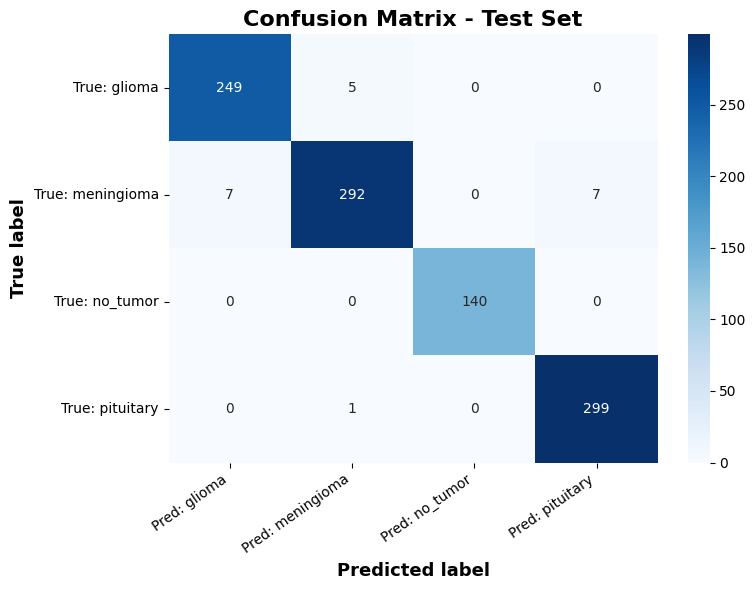

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.png


In [14]:
# =========================
# CONFUSION MATRIX - DARABSZÁM
# =========================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES)))
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_df)

cm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_counts.csv")
cm_df.to_csv(cm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)
plt.title("Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_png = os.path.join(OUT_DIR, "test_confusion_matrix_counts.png")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_csv)
print("Kép mentve:", cm_png)

,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,0.980315,0.019685,0.0,0.000000
True: meningioma,0.022876,0.954248,0.0,0.022876
True: no_tumor,0.000000,0.000000,1.0,0.000000
True: pituitary,0.000000,0.003333,0.0,0.996667


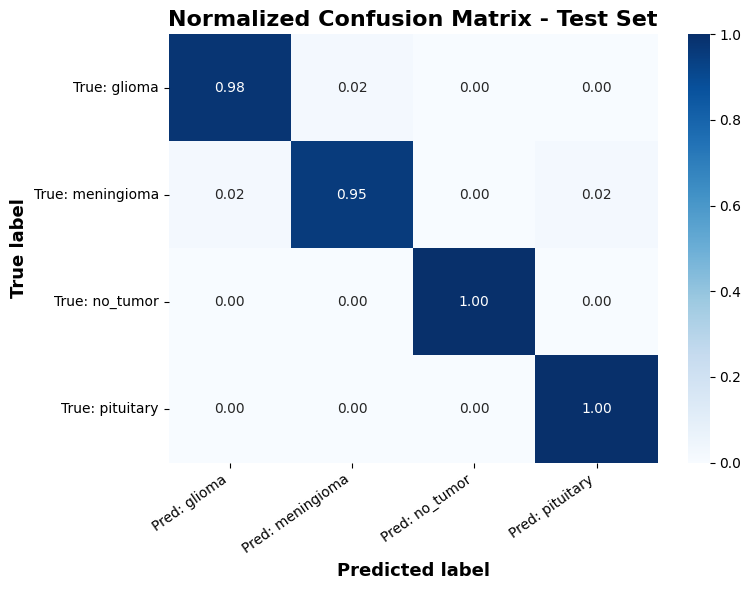

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.png


In [15]:
# =========================
# NORMALIZÁLT CONFUSION MATRIX
# =========================

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_norm_df)

cm_norm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    vmin=0,
    vmax=1
)
plt.title("Normalized Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_png = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.png")
plt.savefig(cm_norm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_norm_csv)
print("Kép mentve:", cm_norm_png)

In [16]:
# =========================
# KÉPENKÉNTI PREDIKCIÓS TÁBLÁZAT
# =========================

pred_rows = []

for i in range(len(y_true)):
    row = {
        "image_path": image_paths[i],
        "true_idx": int(y_true[i]),
        "pred_idx": int(y_pred[i]),
        "true_label": label_map_inv[int(y_true[i])],
        "predicted_label": label_map_inv[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "confidence": float(np.max(y_prob[i]))
    }

    for j, cname in enumerate(CLASS_NAMES):
        row[f"prob_{cname}"] = float(y_prob[i][j])

    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)

display(pred_df.head(20))

pred_csv = os.path.join(OUT_DIR, "test_predictions_per_image.csv")
pred_df.to_csv(pred_csv, index=False)
print("Mentve:", pred_csv)

,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
0,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999512,0.999512,0.000089,4.351139e-06,0.000242
1,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999023,0.999023,0.000021,6.973743e-06,0.000843
2,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,1.000000,1.000000,0.000034,1.609325e-06,0.000013
3,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.967285,0.967285,0.029419,1.859665e-05,0.003071
4,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.950684,0.950684,0.027771,9.715557e-06,0.021408
5,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999512,0.999512,0.000454,4.279613e-05,0.000095
6,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,1.000000,1.000000,0.000028,6.198883e-06,0.000083
7,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,1.000000,1.000000,0.000003,5.364418e-07,0.000006
8,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,1.000000,1.000000,0.000011,1.955032e-05,0.000127
9,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.997070,0.997070,0.000171,1.657009e-05,0.002913


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_predictions_per_image.csv


In [17]:
# =========================
# HIBÁSAN KLASSZIFIKÁLT KÉPEK
# =========================

wrong_df = pred_df[pred_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values(by="confidence", ascending=False)

print("Hibás predikciók száma:", len(wrong_df), "/", len(pred_df))
display(wrong_df.head(50))

wrong_csv = os.path.join(OUT_DIR, "test_misclassified_images.csv")
wrong_df.to_csv(wrong_csv, index=False)
print("Mentve:", wrong_csv)

Hibás predikciók száma: 20 / 1000


,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
532,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.995117,0.995117,0.001999,0.000045,0.002625
280,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.990723,0.990723,0.003294,0.005966,0.000135
224,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.983398,0.016205,0.983398,0.000006,0.000471
412,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.961426,0.961426,0.022247,0.001345,0.014992
228,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.933105,0.037964,0.933105,0.001368,0.027771
233,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.929688,0.067871,0.929688,0.000008,0.002472
29,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.908691,0.089294,0.908691,0.000280,0.001758
91,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.908691,0.089294,0.908691,0.000280,0.001758
454,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,3,meningioma,pituitary,False,0.855469,0.007721,0.136597,0.000103,0.855469
300,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.768066,0.768066,0.023422,0.003521,0.205200


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/test_misclassified_images.csv


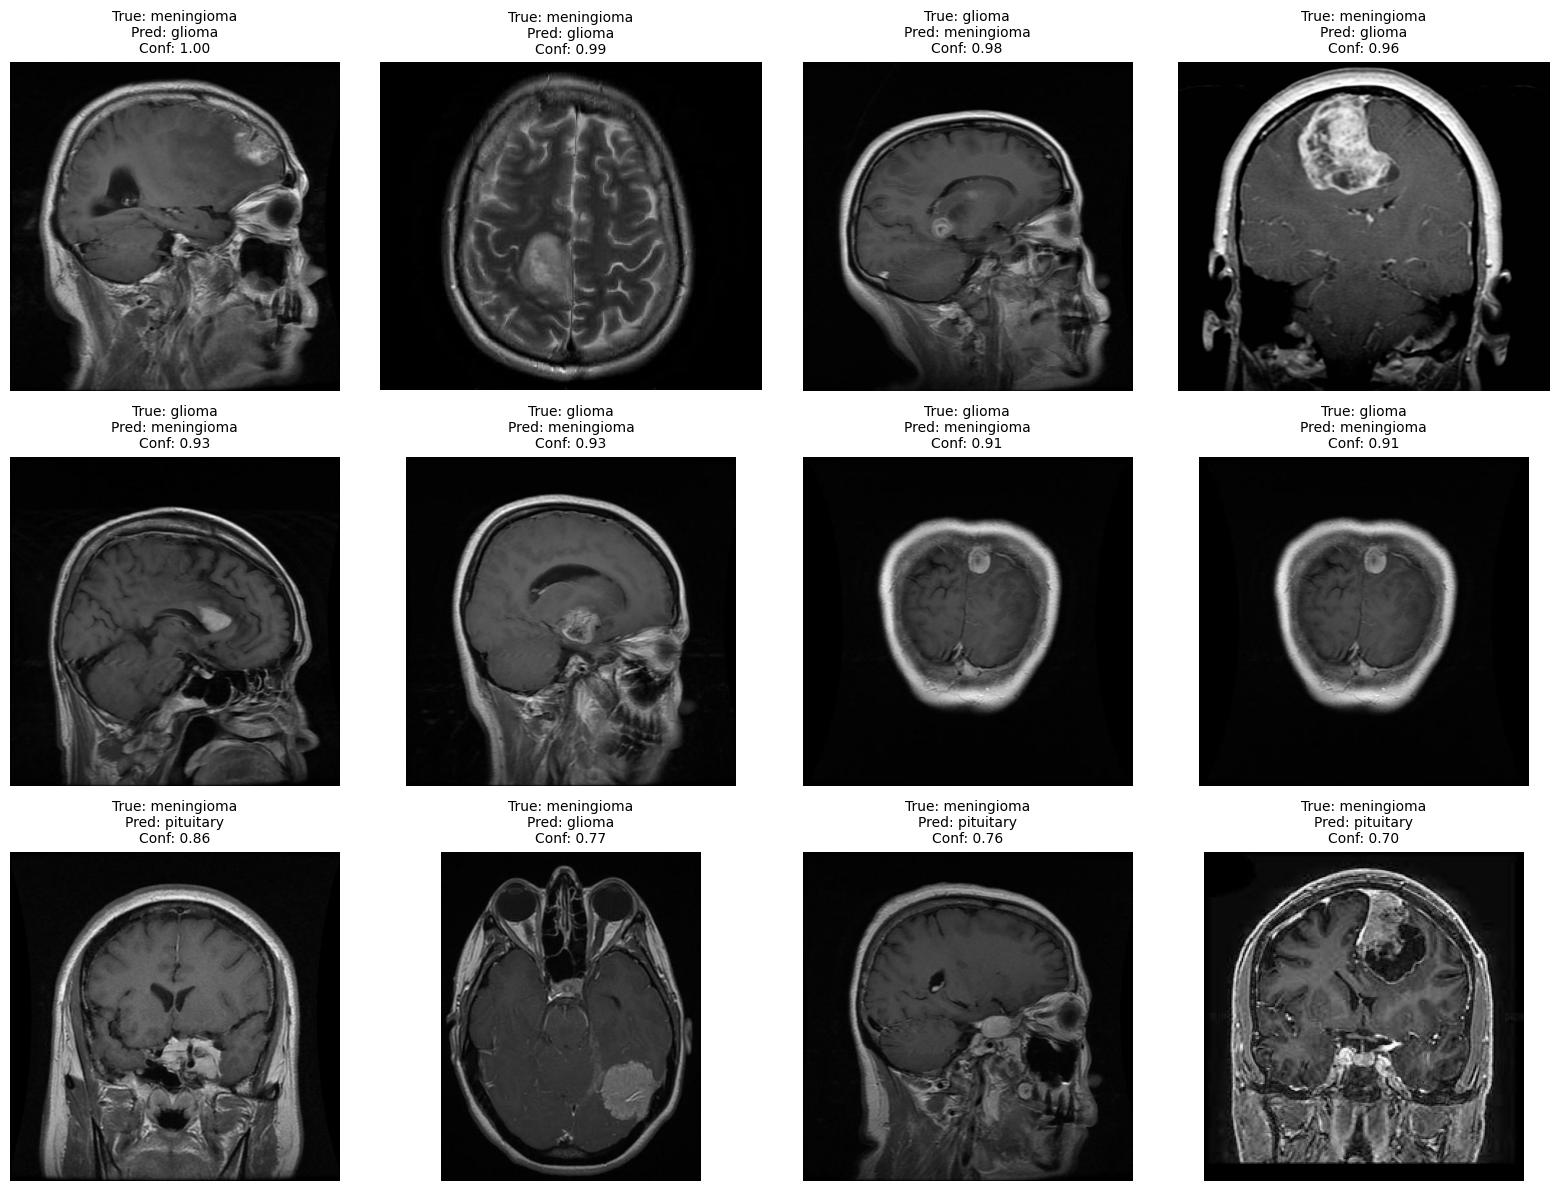

Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL/misclassified_examples.png


In [18]:
# =========================
# HIBÁS PÉLDÁK VIZUALIZÁLÁSA
# =========================

def show_misclassified_examples(wrong_df, max_images=12):
    if len(wrong_df) == 0:
        print("Nincs hibás klasszifikáció.")
        return

    sample_df = wrong_df.head(max_images).copy()
    n = len(sample_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "misclassified_examples.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Mentve:", out_path)

show_misclassified_examples(wrong_df, max_images=12)

In [19]:
# =========================
# ÖSSZES EREDMÉNY LISTÁZÁSA
# =========================

print("Kiértékelés kész.")
print("Eredmények mappája:", OUT_DIR)

print("\nLétrehozott fájlok:")
for f in sorted(os.listdir(OUT_DIR)):
    print(" -", f)

Kiértékelés kész.
Eredmények mappája: /content/drive/MyDrive/Brain MRI/FNO_clas/ResNet50_Fourier_final/test_evaluation_FULL

Létrehozott fájlok:
 - misclassified_examples.png
 - test_classification_report.csv
 - test_confusion_matrix_counts.csv
 - test_confusion_matrix_counts.png
 - test_confusion_matrix_normalized.csv
 - test_confusion_matrix_normalized.png
 - test_file_list.csv
 - test_misclassified_images.csv
 - test_predictions_per_image.csv
 - test_results_table.csv
 - test_summary_metrics.csv
